# A single-band approximation for La$_{2}$CuO$_{4}$: Post-processing and Analysis

In the previous tutorial, you solved an effective one-band model for La$_{2}$CuO$_{4}$ derived from first-principles within DMFT. We will now learn how to analyze and post-process the results obtained in the [previous tutorial](). In this tutorial, you will learn how to:

- Analytically continue Matsubara Green's functions and self-energies

- Post-process and interpret spectral functions and self-energies

### 🧪 Exercise 0: Load the converged DMFT from HDF5

We have pre-converged the DMFT loop for you. The data is saved in HDF5 format, with each group corresponding to an iteration. The data is saved in the file ``ref_data/lco-beta=10.0-U=3.6.h5``. From the last iteration: 

* Load the chemical potential (stored under ``'mu'``),

* The self-energy (stored under ``'Sigma_iw'``),

* The impurity Green's function (stored under ``'G_iw'``).



Plot your Green's function and self-energy.

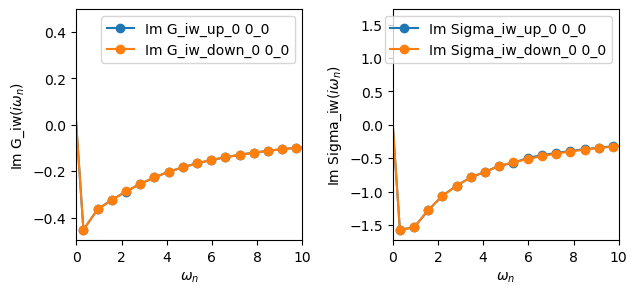

In [1]:
from h5 import HDFArchive
from triqs.gf import MeshImFreq, BlockGf
from triqs.plot.mpl_interface import oplot, plt
import numpy as np

# load data
with HDFArchive('../ref_data/lco-beta=10.0-U=3.6.h5') as ar:
    last_iter = str(len(ar)-1)
    mu = ar[last_iter]['mu']
    Sigma_iw = ar[last_iter]['Sigma_iw']
    G_iw = ar[last_iter]['G_iw']

# plot the data
fig, (ax1,ax2) = plt.subplots(1,2,sharex=True, figsize=(7,3))
oplot(G_iw.imag, 'o-', axes=ax1)
oplot(Sigma_iw.imag, 'o-', axes=ax2)
ax1.set_xlim(0,10)
plt.subplots_adjust(wspace=0.4)
plt.show()

### 🧪 Exercise 1: Estimate Z from the Matsubara self-energy

Using the self-energy that you obtained above, estimate the quasiparticle renormalization factor, which is defined as


$$ Z = (1 - \partial_{\omega_{n}}\text{Im}\Sigma(i\omega_{n}) |_{\omega_{n}\rightarrow 0})^{-1}. $$


We can estimate this quantity in a couple of different ways. The simplest is to just look at the first Matsubara point:


$$ Z \sim \Big (1 - \frac{\mathrm{Im}\Sigma(i\omega_{0})}{\omega_{0}} \Big )^{-1},$$

where $\omega_{0} = \frac{\pi}{\beta}$.

> ⚠️ **Warning**: In practice, the derivatve in the formula for $Z$ is estimated by fitting a polynomial to the self-energy at the first few Matsubara frequencies.

In [2]:
beta = 10.0

Z = 1/(1 - Sigma_iw['up_0'][0,0](0).imag*beta/np.pi)
print(f'Z= {Z}')

Z= 0.16676528809176008


## 🌀 Analytic continuation: from Matsubara to real frequencies

In this section, we will learn how to **analytically continue** our results from Matsubara (imaginary) frequencies onto the real-frequency axis, so that we may plot spectral functions. Because analytic continuation is an ill-posed problem, it is notoriously unstable, and the method itself remains an active area of research. However, there are two common analytic continuation techniques: Padé analytic continuation and the maximum entropy (MaxEnt) method. In this section, we will use Padé analytic continuation since it is simpler. We will then compare our results with MaxEnt.

### ❓The problem

We assume the Matsubara Green's function $G(i\omega_{n})$ corresponds to a dynamic correlation function $G(\omega)$, where $\omega_{n}$ is the Matsubara frequency, and $\omega$ is the real frequency. The function $G(z)$ is analytic in the whole upper complex plane of $z$ excluding the real axis. The retarded Green's function can be obtained by analytic continuation: $$G(\omega) = G(i\omega_{n}\rightarrow \omega + i0^{+}).$$ The spectral function $A(\omega)$ is determined by taking the imaginary part of $G(\omega + i0^{+})$ using the formula

$$ A(\omega) = -\frac{1}{\pi}\mathrm{Im}G(\omega + i0^{+}).$$

### 📐 Padé method

Padé analytic continuation is based on the assumption that the Matsubara Green's function can be approximated by a rational function of degree $r$:

$$ G(z) = \frac{\sum_{i=0}^{r-1} p_{i}z^{i}}{\sum_{j=0}^{r-1}q_{j}z^{j} + z^{r}}, $$

where $p_{i}$ and $q_{j}$ are complex. The coefficients can be determined by solving $2r$ linear equations from $2r$ arbitrary but different input points ${i\omega_{n}, G(i\omega_{n})}$. Once the coefficients are determined, we replace $z$ with $\omega + i0^{+}$ to obtain the retarded correlation function.

### 🧪 Exercise 2: Analytically continue the Matsubara Green's function

In this exercise, we will analytically continue the Matsubara Green's function onto the real frequency axis.

#### 🧩 Your task

1. Set up a ``BlockGf`` with a real frequency mesh ``MeshReFreq``.
2. For each block in the Matsubara Green's function, use the ``set_from_pade`` method to obtain the real-frequency Green's function for each block.
3. Plot the resulting spectral function using the formula $A(\omega) = -\frac{1}{\pi}\text{Im}G(\omega + i0^{+})$.

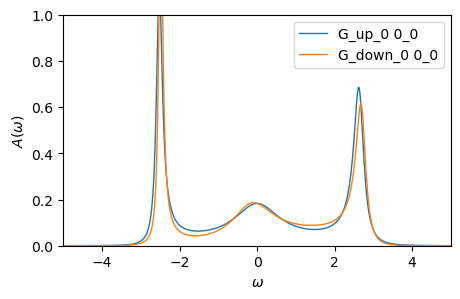

In [3]:
from triqs.gf import MeshReFreq

n_w = 1000
window = (-10, 10)

# Step 1: set up real-frequency mesh and BlockGf

## get the block shape of the Matsubara Green's function
gf_struct = [ (bl, g.target_shape[0]) for bl, g in G_iw ]

## set up real-frequency mesh
mesh = MeshReFreq(window, n_w)

## construct Block Green's function on real-frequency mesh
G_w = BlockGf(mesh=mesh, gf_struct=gf_struct)

# Step 2: loop over the blocks and call set_from_pade
n_points = 25
freq_offset = 0.0
for block, g in G_w: 
    g.set_from_pade(G_iw[block], n_points=n_points, freq_offset=freq_offset)

# Step 3: plot the spectral function: A(w) = -1/π ImG(ω)

plt.figure(figsize=(5,3))
oplot(-1/np.pi*G_w.imag, lw=1)
plt.ylabel(r'$A(\omega)$'); plt.xlim(-5,5); plt.ylim(0, 1)
plt.show()

> ⚠️ **Warning**: The Padé method can be sensitive to the choice of ``n_points``, which corresponds to the amount of Matsubara data you allow the algorithm to see. Try changing this parameter to see how the resulting spectral function changes.

### 🌀 MaxEnt for a Green's function

Let's compare our Padé results to those obtained using the maximum entropy method. Within the TRIQS ecosystem, we have a maximum entropy suite (TRIQS/maxent) which allows one to analytically continue TRIQS Green's function objects to obtain real-frequency spectra. Here, we have abstracted away much of the boilerplate code and provide you with a free function ``Aw_from_maxent`` inside the ``triqs_tutorials_utils.maxent`` module. Let's try loading this module:

```python

from triqs_tutorials_utils.maxent import Aw_from_maxent

```

Then use the function ``Aw_from_maxent``, which takes as an argument a Matsubara Green's function.

> 💡 **Tip**: Don't forget about the ``?function_name`` functionality of Jupyter notebooks, which allows you to check the API of a function within the notebook itself.


Plot your results for MaxEnt and Padé.

> ⚠️ **Warning:** The maxent module you are using is not yet part of the TRIQS library. You are using a prototype function that is included with these tutorials.

In [4]:
from triqs_tutorials_utils.maxent import Aw_from_maxent

mesh, Aw = Aw_from_maxent(G_iw, omega_min=-10, 
                                omega_max= 10, 
                                alpha_min=1e-6, 
                                alpha_max=1e2, 
                                n_alpha_points=50, 
                                n_omega_points=200, 
                                error=0.02)

Calculating diagonal elements.
Calling MaxEnt for element 0 0


Starting serial run at: 2025-09-01 09:24:03.435905


2025-09-01 09:24:03.711577
MaxEnt run
TRIQS application maxent
Copyright(C) 2018 Gernot J. Kraberger
Copyright(C) 2018 Simons Foundation
Authors: Gernot J. Kraberger and Manuel Zingl
This program comes with ABSOLUTELY NO WARRANTY.
This is free software, and you are welcome to redistributeit under certain conditions; see file LICENSE.
Please cite this code and the appropriate original papers (see documentation).

Minimal chi2: 0.0009712063453840789
scaling alpha by a factor 1507 (number of data points)
alpha[ 0] =   1.50700000e+05, chi2 =   1.12895743e+04, n_iter=       5 
alpha[ 1] =   1.03477981e+05, chi2 =   9.19236048e+03, n_iter=       4 
alpha[ 2] =   7.10530361e+04, chi2 =   7.03532044e+03, n_iter=       4 
alpha[ 3] =   4.87884852e+04, chi2 =   5.11242698e+03, n_iter=       4 
alpha[ 4] =   3.35005570e+04, chi2 =   3.62352310e+03, n_iter=       4 
alpha[ 5] =   2.30031188e+04, chi2 =   2.58864234e+03, n_iter=       4 
alpha[ 6] =   1.57950649e+04, chi2 =   1.90504813e+03, n_iter

alpha[22] =   3.85723872e+01, chi2 =   6.60437587e+00, n_iter=       4 
alpha[23] =   2.64856851e+01, chi2 =   3.89866436e+00, n_iter=       4 
alpha[24] =   1.81863651e+01, chi2 =   2.32684102e+00, n_iter=       4 
alpha[25] =   1.24876466e+01, chi2 =   1.41806689e+00, n_iter=       4 
alpha[26] =   8.57462811e+00, chi2 =   8.86466855e-01, n_iter=       4 
alpha[27] =   5.88775849e+00, chi2 =   5.68991277e-01, n_iter=       4 
alpha[28] =   4.04282256e+00, chi2 =   3.75880565e-01, n_iter=       4 
alpha[29] =   2.77599944e+00, chi2 =   2.57600162e-01, n_iter=       7 
alpha[30] =   1.90613681e+00, chi2 =   1.85673350e-01, n_iter=       7 


alpha[31] =   1.30884664e+00, chi2 =   1.42735650e-01, n_iter=       8 
alpha[32] =   8.98718034e-01, chi2 =   1.17715871e-01, n_iter=       8 
alpha[33] =   6.17103700e-01, chi2 =   1.03468302e-01, n_iter=       9 
alpha[34] =   4.23733543e-01, chi2 =   9.54673000e-02, n_iter=       9 


...

alpha[44] =   9.87278735e-03, chi2 =   2.79179769e-02, n_iter=      69 


alpha[45] =   6.77913803e-03, chi2 =   2.72376283e-02, n_iter=      86 


alpha[46] =   4.65488730e-03, chi2 =   2.66046561e-02, n_iter=     109 


alpha[47] =   3.19627299e-03, chi2 =   2.60309841e-02, n_iter=     138 
alpha[48] =   2.19471716e-03, chi2 =   2.60309841e-02, n_iter=       1 


alpha[49] =   1.50700000e-03, chi2 =   2.50966327e-02, n_iter=     306 
MaxEnt loop finished in 0:00:03.435566
appending
Calculating off-diagonal elements using default model from diagonal solution


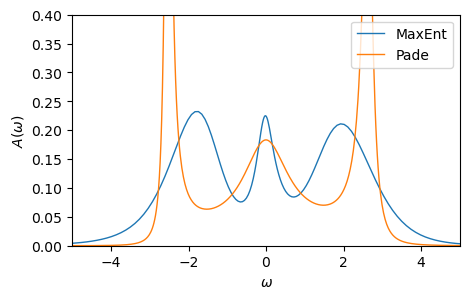

In [5]:
plt.figure(figsize=(5,3))
plt.plot(mesh, Aw['up_0'].get_A_out('LineFitAnalyzer')[0,0].real, lw=1, label='MaxEnt')
oplot(-1/np.pi*G_w['up_0'].imag, lw=1, label='Pade')
plt.ylabel(r'$A(\omega)$'); plt.xlim(-5,5); plt.ylim(0, 0.4)
plt.show()

As you can see, the two analytic continuation methods, Padé and MaxEnt, yield different results that share only some qualitative features. MaxEnt is generally more robust to numerical noise and produces smooth spectral functions, making it a reliable choice when the input data are noisy, as is often the case in quantum Monte Carlo simulations. Padé approximants, by contrast, can capture fine structures with the high accuracy when provided with very precise data, but they are highly sensitive to noise as you've observed.

In practice, MaxEnt is typically preferred for stochastic data, while Padé is more useful when working with high-precision input or for cross-checking features suggested by MaxEnt. Both methods remain viable and can produce high-quality spectra when applied in the appropriate context.

### 🧪 Exercise 3: Understanding your spectral function

Let's take a closer look at the spectral functions that we just obtained. Specifically, let's see if they reproduce the features that we expect: spectral weight transfer into the upper and lower Hubbard bands around $\pm U/2$, as well as the width of the quasiparticle peak, which goes as $\sim -Z\mathrm{Im}\Sigma(0)$.

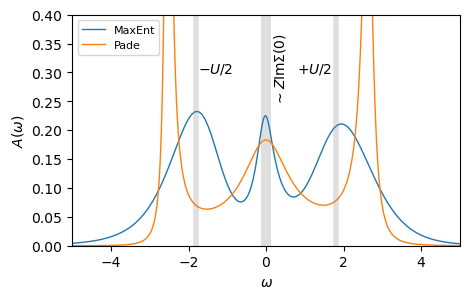

In [6]:
# plot from above
plt.figure(figsize=(5,3))
plt.plot(mesh, Aw['up_0'].get_A_out('LineFitAnalyzer')[0,0].real, lw=1, label='MaxEnt')
oplot(-1/np.pi*G_w['up_0'].imag, lw=1, label='Pade')
plt.ylabel(r'$A(\omega)$'); plt.xlim(-5,5); plt.ylim(0, 0.4)
plt.legend(loc='upper left', fontsize = 8)

# Step 1: add lines where the upper and lower Hubbard bands should be
U = 3.6

# We expect upper and lower Hubbard bands at +/- U/2
plt.axvline(+U/2, color='grey', lw=4, alpha=0.25); plt.axvline(-U/2, color='grey', lw=4, alpha=0.25)
plt.text(-1.75, 0.3, r'$-U/2$'); plt.text(0.8, 0.3, r'$+U/2$')

# Step 2: add a column that is proportional to the width of the quasiparticle peak

# We expect the width of the peak to be -Z*ImΣ(0)
width = -Z*Sigma_iw['up_0'][0,0](0).imag
plt.axvspan(-0.5*width, 0.5*width, color='grey', lw=0, alpha=0.25); plt.text(0.15, 0.25, r'$\sim Z\mathrm{Im}\Sigma(0)$', rotation=90)

plt.show()

### 🧪 Exercise 4: Analytically continue the Matsubara self-energy

In this exercise, we will analytically continue the Matsubara self-energy onto the real-frequency axis. Due to implementation details, you can directly use the same Python code to analytically continue a self-energy in the same way as a Green's function in TRIQS.

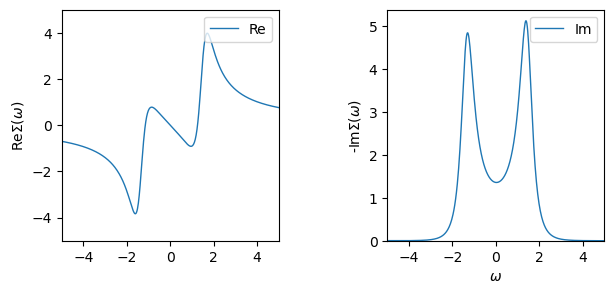

In [7]:
n_w = 1000
window = (-10, 10)

mesh = MeshReFreq(window, n_w)

# Step 1: construct Block Green's function on real-frequency mesh
Sigma_w_pade = BlockGf(mesh=mesh, gf_struct=gf_struct)

# Step 2: loop over the blocks and call set_from_pade
n_points = 25
freq_offset = 0.0
for block, g in Sigma_w_pade: g.set_from_pade(Sigma_iw[block], n_points=n_points, freq_offset=freq_offset)

# Step 3: plot the real and imaginary part of the self-energy. Is your result physical?
fig, ax = plt.subplots(1,2,sharex=True, figsize=(7,3))
oplot(Sigma_w_pade['up_0']-Sigma_w_pade['up_0'][0,0](0.0).real, axes=ax[0],mode='R', lw=1, label='Re')
oplot(-Sigma_w_pade['up_0'], axes=ax[1], mode='I', lw=1, label='Im')
ax[0].set_ylim(-5,5); ax[0].set_xlim(-5,5); ax[1].set_ylim(0, ); 
ax[0].set_xlabel('')
ax[0].set_ylabel(r'Re$\Sigma(\omega)$'); ax[1].set_ylabel(r'-Im$\Sigma(\omega)$')
plt.subplots_adjust(wspace=0.5)
plt.show()

### 🌀 MaxEnt for a Self-energy

Again, let's compare our Padé results to those obtained using the maximum entropy method. This time, you will use the free function ``Sigma_w_from_maxent`` inside the ``triqs_tutorials_utils.maxent`` module. Let's try loading this module:

```python

from triqs_tutorials_utils.maxent import Sigma_w_from_maxent

```

Then use the function ``Sigma_w_from_maxent``, which takes as an argument a Matsubara self-energy.

In [8]:
from triqs_tutorials_utils.maxent import Sigma_w_from_maxent

Sigma_w = Sigma_w_from_maxent(Sigma_iw, error=0.02)

Calculating diagonal elements.
Calling MaxEnt for element 0 0


2025-09-01 09:24:11.510630
MaxEnt run
TRIQS application maxent
Copyright(C) 2018 Gernot J. Kraberger
Copyright(C) 2018 Simons Foundation
Authors: Gernot J. Kraberger and Manuel Zingl
This program comes with ABSOLUTELY NO WARRANTY.
This is free software, and you are welcome to redistributeit under certain conditions; see file LICENSE.
Please cite this code and the appropriate original papers (see documentation).

Minimal chi2: 0.0013693112300262823
scaling alpha by a factor 1507 (number of data points)
alpha[ 0] =   1.50700000e+05, chi2 =   1.36069998e+04, n_iter=       5 
alpha[ 1] =   1.03477981e+05, chi2 =   1.14757941e+04, n_iter=       4 
alpha[ 2] =   7.10530361e+04, chi2 =   9.15524396e+03, n_iter=       4 
alpha[ 3] =   4.87884852e+04, chi2 =   6.90782155e+03, n_iter=       4 
alpha[ 4] =   3.35005570e+04, chi2 =   4.98415427e+03, n_iter=       4 
alpha[ 5] =   2.30031188e+04, chi2 =   3.50841082e+03, n_iter=       4 
alpha[ 6] =   1.57950649e+04, chi2 =   2.46271071e+03, n_iter

alpha[21] =   5.61748374e+01, chi2 =   1.50562205e+01, n_iter=       4 
alpha[22] =   3.85723872e+01, chi2 =   9.42693025e+00, n_iter=       4 
alpha[23] =   2.64856851e+01, chi2 =   5.84357371e+00, n_iter=       4 
alpha[24] =   1.81863651e+01, chi2 =   3.62216528e+00, n_iter=       4 
alpha[25] =   1.24876466e+01, chi2 =   2.26538899e+00, n_iter=       4 
alpha[26] =   8.57462811e+00, chi2 =   1.43860843e+00, n_iter=       7 
alpha[27] =   5.88775849e+00, chi2 =   9.30702756e-01, n_iter=       7 


alpha[28] =   4.04282256e+00, chi2 =   6.14649761e-01, n_iter=       8 
alpha[29] =   2.77599944e+00, chi2 =   4.15741982e-01, n_iter=       9 
alpha[30] =   1.90613681e+00, chi2 =   2.89782534e-01, n_iter=      10 


alpha[31] =   1.30884664e+00, chi2 =   2.09920814e-01, n_iter=      11 
alpha[32] =   8.98718034e-01, chi2 =   1.59348402e-01, n_iter=      12 
alpha[33] =   6.17103700e-01, chi2 =   1.27351609e-01, n_iter=      13 


...

alpha[43] =   1.43782188e-02, chi2 =   2.60517306e-02, n_iter=      53 
alpha[44] =   9.87278735e-03, chi2 =   2.55393495e-02, n_iter=      67 


alpha[45] =   6.77913803e-03, chi2 =   2.50569552e-02, n_iter=      85 


alpha[46] =   4.65488730e-03, chi2 =   2.46140837e-02, n_iter=     107 


alpha[47] =   3.19627299e-03, chi2 =   2.42193073e-02, n_iter=     137 
alpha[48] =   2.19471716e-03, chi2 =   2.42193073e-02, n_iter=       1 


alpha[49] =   1.50700000e-03, chi2 =   2.35977979e-02, n_iter=     306 
MaxEnt loop finished in 0:00:03.573914
appending
Calculating off-diagonal elements using default model from diagonal solution


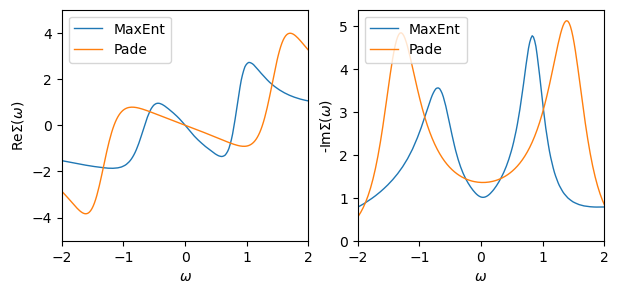

In [9]:
fig, ax = plt.subplots(1,2,sharex=True, figsize=(7,3))

# maxent
oplot(Sigma_w['up_0']-Sigma_w['up_0'][0,0](0.0).real, axes=ax[0], mode='R', lw=1, label='MaxEnt')
oplot(-Sigma_w['up_0'], axes=ax[1], mode='I', lw=1, label='MaxEnt')

# pade
oplot(Sigma_w_pade['up_0']-Sigma_w_pade['up_0'][0,0](0.0).real, axes=ax[0], mode='R', lw=1, label='Pade')
oplot(-Sigma_w_pade['up_0'], axes=ax[1], mode='I', lw=1, label='Pade')

ax[0].legend(loc='upper left'); ax[1].legend(loc='upper left')
ax[0].set_ylim(-5,5); ax[0].set_xlim(-2,2); ax[1].set_ylim(0, ); 
ax[0].set_ylabel(r'Re$\Sigma(\omega)$'); ax[1].set_ylabel(r'-Im$\Sigma(\omega)$')
plt.show()

### 🧪 Exercise 5: Estimate Z and the scattering rate from the self-energy

Using the self-energy that you obtained above, estimate the quasiparticle renormalization factor and the scattering rate, which are defined as:


$$ Z = (1 - \partial_{\omega}\text{Re}\Sigma(\omega) |_{\omega\rightarrow0})^{-1}. $$


The scattering rate is proportional to $-\mathrm{Im}\Sigma(\omega=0)$. For $Z$, you can fit a linear line to the low-frequency data in the real part of the spectrum and use the slope of the line to estimate the derivative. For the scattering rate, you can ask what is the value of $\Sigma(\omega = 0)$.

Compare your result to Exercise 1.

In [10]:
x = np.linspace(-0.2, 0.2,10)
y = [Sigma_w['up_0'][0,0](xx).real for xx in x]
dSdw = np.polyfit(x,y,1)[0]
Z = 1/(1 - dSdw)
print(f'     Z  =  {Z}')
print(f'-ImΣ(0) =  {-Sigma_w['up_0'][0,0](0.0).imag}')

     Z  =  0.2511944569407111
-ImΣ(0) =  1.0172608915565609


## 📊 Plotting your results

### 🧪 Exercise 6: Plot the momentum-resolved spectral function along the high-symmetry path in the Brillouin zone

Let's plot the spectral function along a high-symmetry path in the Brillouin zone. This means we will compute


$$ A(k,\omega) = -\frac{1}{\pi} \mathrm{Im} \mathrm{Tr}G_{\mathrm{latt}}(k, \omega), $$

where $G_{\mathrm{latt}}$ is the lattice Green's function defined previously. First, we will prepare a list of $k$ points along a high-symmetry direction in the first Brillouin zone of La$_{2}$CuO$_{4}$. Using our converged chemical potential ($\mu$) and self-energy in real frequencies ($\Sigma(\omega)$), we can compute $A(k,\omega)$ with the utility function ``momentum_resolved_spectral_function``.

Additionally, we can add the quasiparticle (QP) dispersion and compare. The QP dispersion corresponds to the renormalized electronic dispersion that emerges from electron correlations, describing long-lived excitations whose energies and spectral weight are modified by interactions relative to the non-interacting band structure.

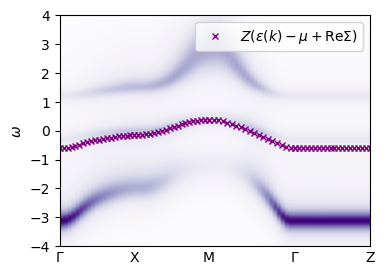

In [11]:
import triqs_modest as modest
from triqs.lattice.utils import k_space_path
from triqs_tutorials_utils.mpl_interface import momentum_resolved_spectral_function, plot_spectral_function

# create high-symmetry path
G = [0.00,  0.00,  0.00]
X = [0.25, -0.25,  0.25]
M = [0.00,  0.00,  0.50]
Z = [0.25,  0.25, -0.25]

segments = [(G,X), (X,M), (M, G), (G,Z)]
k_points, k_lin, k_ticks = k_space_path(segments, num=20)


# load in obe or the TB hamiltonian
obe  = modest.one_body_elements_from_wannier90("../data/mlwf/lco", "NonPolarized", [modest.AtomicOrbs(dft_idx=0, cls_idx=0, l=2, dim=1)])

# compute the dispersion along the high-symmetry directions
e_k = obe.H[0].eigenvalues(k_points).real

# compute the spectral function
A_kw = momentum_resolved_spectral_function(e_k, mu, Sigma_w['up_0'], broadening=0.1)

w_min, w_max = -10, +10
plt.figure(figsize=(4,3))

# plot the spectral function
plot_spectral_function(A_kw, k_lin, w_min, w_max, k_ticks, [r'$\Gamma$', 'X', 'M', r'$\Gamma$', 'Z'], cmap='Purples', vmin=0)

# plot the QP dispersion
Z = 0.25119445637993476
plt.plot(k_lin, Z*(e_k[:,0] - mu + Sigma_w['up_0'][0,0](0).real), 'x', ms=5, color='purple', label=r'$Z(\varepsilon(k)-\mu + \mathrm{Re}\Sigma)$')

plt.legend()
plt.ylim(-4,4)
plt.show()

### 🧪 Exercise 7: Describe your results

In a few words, describe your spectral function results $A(k, \omega)$. Compare the interacting spectrum to the non-interacting you graphed in [Tutorial 01](01-dft.ipynb). Can you connect any of these changes to features in the self-energy?

From the momentum-resolved spectral function shown above, we see two distinct features: upper and lower Hubbard bands forming around $\pm U/2$ and significant band renormalization due to the small quasiparticle renormalization factor, $Z$.